#  End-to-End Handwritten Digit Recognition project 

# Problem Statement :
### The objective of this project is to develop a Convolutional Neural Network (CNN) model that accurately recognizes and classifies handwritten digits (0–9) from grayscale images. The model is trained on the MNIST dataset and integrated into a prediction system for real-time handwritten digit recognition.
# Objective: Build a complete real-time AI application that recognizes digits written in the air using your trained CNN model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

In [2]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


In [4]:
#CHeck data types 
print("Image Data Type :", X_train.dtype)
print("Label Data Type :", y_train.dtype)

Image Data Type : uint8
Label Data Type : uint8


In [5]:
#image Dimensions 
print("Each image shape:", X_train[0].shape)

Each image shape: (28, 28)


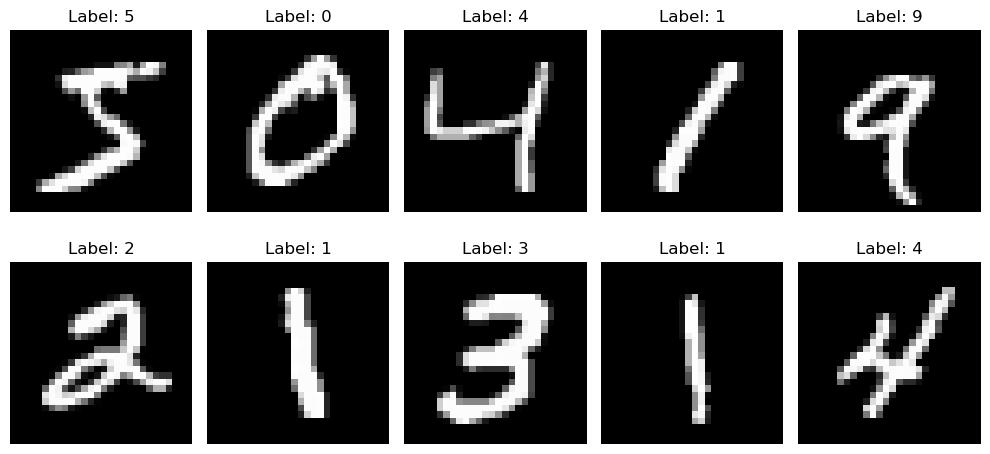

In [6]:
# Display Sample images
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
#check pixel value range 
print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


# Image Preprocessing

## 1. Normalize Pixel Values

In [10]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

## 2. Reshape Images

In [11]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


## 3. One-Hot Encode Labels

In [13]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape :", y_test.shape)

Training Labels Shape: (60000, 10)
Testing Labels Shape : (10000, 10)


In [14]:
print("Image Shape :", X_train[0].shape)
print("Pixel Value Range :", X_train.min(), "to", X_train.max())
print("One-Hot Encoded Label :", y_train[0])

Image Shape : (28, 28, 1)
Pixel Value Range : 0.0 to 1.0
One-Hot Encoded Label : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# Feature Extraction

## In this project, manual feature extraction is not required. The Convolutional Neural Network (CNN) automatically learns and extracts important features such as edges, corners, curves, textures, and digit patterns directly from the input images through its convolutional layers. These learned features are then used for accurate digit classification.


# Build a Baseline CNN Model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [16]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         692,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9515 - loss: 0.1622 - val_accuracy: 0.9805 - val_loss: 0.0593
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9832 - loss: 0.0549 - val_accuracy: 0.9821 - val_loss: 0.0516
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9891 - loss: 0.0350 - val_accuracy: 0.9863 - val_loss: 0.0393
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9926 - loss: 0.0235 - val_accuracy: 0.9816 - val_loss: 0.0549
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9948 - loss: 0.0163 - val_accuracy: 0.9865 - val_loss: 0.0481
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9957 - loss: 0.0130 - val_accuracy: 0.9864 - val_loss: 0.0445
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9969 - loss: 0.0091 - val_accuracy: 0.9825 - val_loss: 0.0584
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9977 - loss: 0

In [20]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9858 - loss: 0.0668 
Test Loss: 0.06677442789077759
Test Accuracy: 0.98580002784729


# Hyper Parameter Tuning

In [28]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [29]:
def build_model(hp):
    model = Sequential()

    model.add(
        Conv2D(
            filters=hp.Choice('filters', [16, 32, 64]),
            kernel_size=(3, 3),
            activation='relu',
            input_shape=(28, 28, 1)
        )
    )

    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())

    model.add(
        Dense(
            units=hp.Choice('dense_units', [64, 128, 256]),
            activation='relu'
        )
    )

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=hp.Choice('optimizer', ['adam', 'rmsprop']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [30]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='cnn_tuning',
    project_name='mnist_cnn'
)

In [31]:
tuner.search(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Trial 5 Complete [00h 01m 13s]
val_accuracy: 0.9861000180244446

Best val_accuracy So Far: 0.9879999756813049
Total elapsed time: 00h 07m 05s


In [32]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Filters      :", best_hp.get('filters'))
print("Best Dense Units  :", best_hp.get('dense_units'))
print("Best Optimizer    :", best_hp.get('optimizer'))

Best Filters      : 32
Best Dense Units  : 256
Best Optimizer    : rmsprop


# Model Building with the Best CNN Model

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

final_model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    
    Flatten(),
    
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

final_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = final_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9564 - loss: 0.1430 - val_accuracy: 0.9819 - val_loss: 0.0567
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9850 - loss: 0.0487 - val_accuracy: 0.9852 - val_loss: 0.0419
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9908 - loss: 0.0303 - val_accuracy: 0.9864 - val_loss: 0.0407
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9942 - loss: 0.0192 - val_accuracy: 0.9869 - val_loss: 0.0410
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9959 - loss: 0.0130 - val_accuracy: 0.9880 - val_loss: 0.0416
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9976 - loss: 0.0077 - val_accuracy: 0.9877 - val_loss: 0.0427
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9984 - loss: 0.0056 - val_accuracy: 0.9866 - val_loss: 0.0539
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9990 - 

# Evaluate the model

In [34]:
loss, accuracy = final_model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9893 - loss: 0.0594
Test Loss: 0.0594
Test Accuracy: 0.9893


## 2. Plot Training & Validation Accuracy

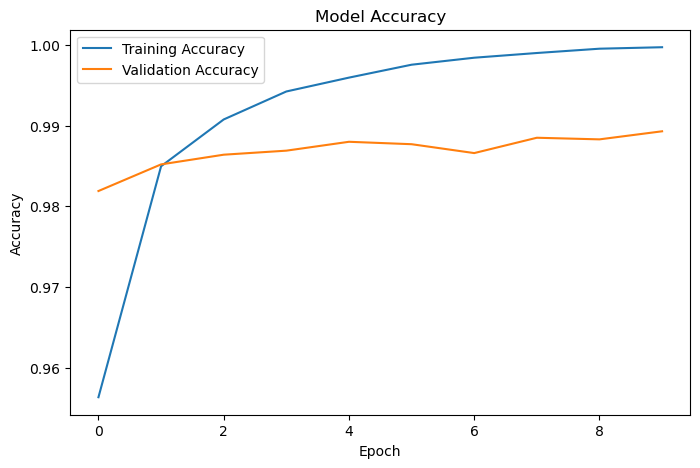

In [35]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Generate Predictions

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = final_model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


## Display Some Predictions

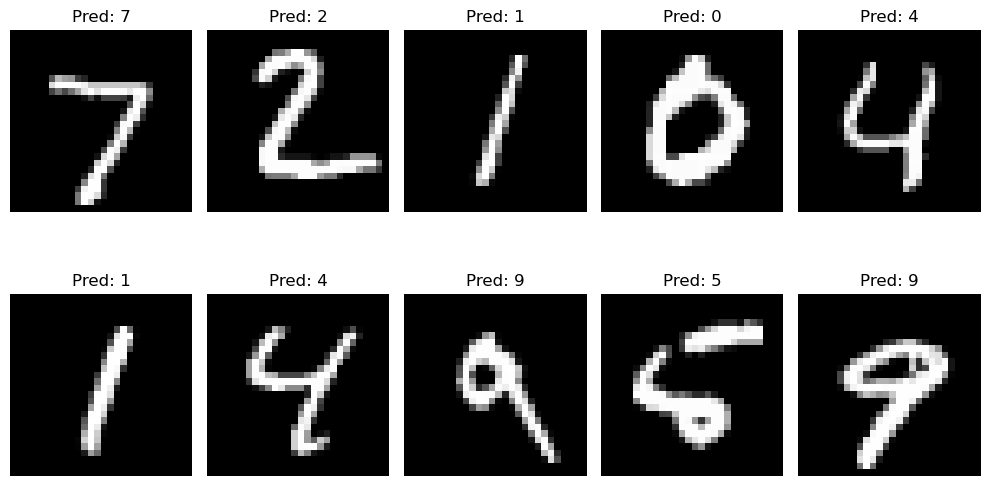

In [37]:
plt.figure(figsize=(10,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred_classes[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Model Saving

In [38]:
final_model.save("handwritten_digit_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [40]:
from tensorflow.keras.models import load_model

model = load_model("handwritten_digit_cnn.keras")

print("Model loaded successfully!")

Model loaded successfully!
